# Day 05｜從一筆資料走到量測分數

今天把前幾章的狀態、量子閘與量測接成完整流程：輸入一個介於 0 與 1 的數字，轉成角度，執行電路，再把量測結果整理成 −1 到 +1 的分數。每一步都可以和已知公式核對。

這稱為前向計算。本例沒有更新權重，也沒有訓練好的分類模型。先選取專案 `.venv/bin/python` 作為執行環境，再從第一格依序執行全部內容。

In [1]:
from pathlib import Path
import sys
import numpy as np

root = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "articles/day05/pipeline.py").exists()), None)
if root is None:
    raise RuntimeError("請從 repository 根目錄或 notebooks/ 開啟 Notebook")
sys.path.insert(0, str(root))
sys.path.insert(0, str(root / "articles/day05"))
from articles.day03.quantum_gates import H, KET_ZERO, apply_gate, probabilities
from articles.day04.bell_state import bell_state, exact_probabilities
from pipeline import encode, state_vector, prediction_from_counts, run_pipeline
print("Python:", sys.version.split()[0], "NumPy:", np.__version__)

Python: 3.12.7 NumPy: 2.2.6


## 1. 看清楚資料經過哪些步驟

輸入先由一般電腦轉成角度，量子電路依角度運算，量測產生計數，再由一般電腦算出分數與誤差。下面的圖標出每個階段；更新權重的訓練流程會在後續加入。

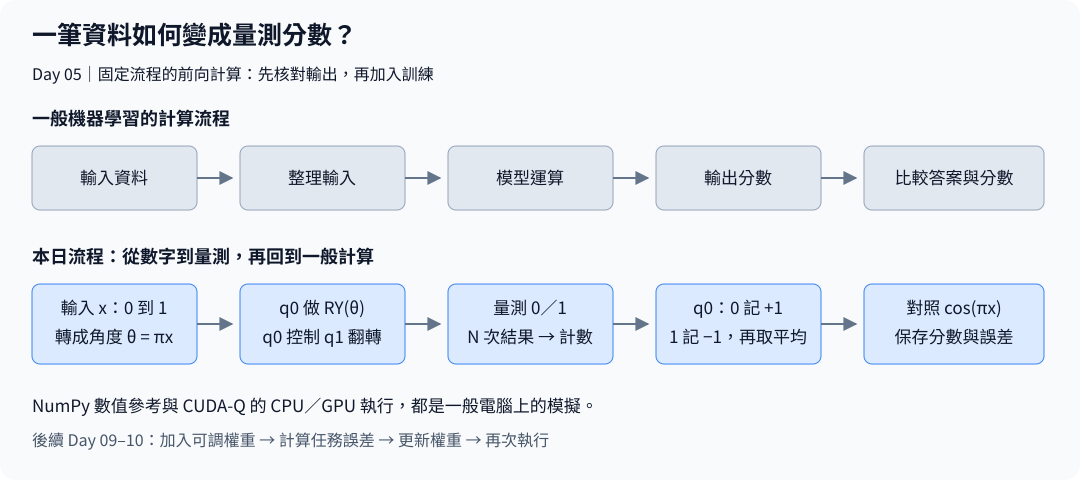

In [2]:
from IPython.display import SVG, display
display(SVG(filename=str(root / "figures/day05_pipeline.svg")))

## 2. 回顧振幅與機率

H 閘把 `|0⟩` 變成兩項振幅都是 `1/√2` 的狀態。它約等於 0.7071，取絕對值平方後才是 0.5。下面同時印出振幅與機率，並檢查直接量測時 0、1 是否各半。

In [3]:
plus = apply_gate(H, KET_ZERO)
print("amplitudes:", plus)
print("Z probabilities:", probabilities(plus))
np.testing.assert_allclose(probabilities(plus), [0.5, 0.5], atol=1e-12)

amplitudes: [0.70710678+0.j 0.70710678+0.j]
Z probabilities: [0.5 0.5]


## 3. 回顧貝爾態與硬幣混合

貝爾態與「先丟硬幣，再準備 00 或 11」在 Z 基底都只出現 00、11，各一半。改用 X 基底，貝爾態仍只出現相同結果，混合態則四種結果各占四分之一。下面核對這兩種已知準備，提醒我們機率表要連同量測方式一起讀。

In [4]:
print("Bell amplitudes:", bell_state())
for name in ("bell", "mixture"):
    for basis in ("Z", "X"):
        print(name, basis, exact_probabilities(name, basis))
np.testing.assert_allclose(exact_probabilities("mixture", "X"), [0.25]*4, atol=1e-12)

Bell amplitudes: [0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]
bell Z [0.5 0.  0.  0.5]
bell X [0.5 0.  0.  0.5]
mixture Z [0.5 0.  0.  0.5]
mixture X [0.25 0.25 0.25 0.25]


## 4. 讓輸入決定角度

本例使用 `θ = πx`，對第一個位元做 RY，再用它控制第二個位元翻轉。輸出狀態是 `cos(θ/2)|00⟩ + sin(θ/2)|11⟩`。

當 x = 0.5，角度是 π/2，兩個振幅都是 `1/√2`，正好回到 Day4 的貝爾態。下面以此作為能直接核對的輸入。θ 由輸入公式決定，還不是訓練學到的權重。

In [5]:
x = 0.5
print("x:", x, "theta:", encode(x))
print("state:", state_vector(x))
np.testing.assert_allclose(state_vector(x), bell_state(), atol=1e-12)

x: 0.5 theta: 1.5707963267948966
state: [0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]


## 5. 把出現次數換成分數

只看第一個位元：0 記 +1，1 記 −1，再取平均，便是 Z0 期望值的估計。下面用 493 個 00、507 個 11 示範，分數是 `(493−507)/1000 = −0.014`。

這個分數與「兩位元是否相同」不同；後者在這批計數中是 1。一般的後處理公式仍需保留 01、10，才能正確處理其他計數。

In [6]:
counts = {"00": 493, "01": 0, "10": 0, "11": 507}
print("Z0 estimate:", prediction_from_counts(counts))
assert abs(prediction_from_counts(counts) + 0.014) < 1e-12

Z0 estimate: -0.014


## 6. 用 NumPy 執行完整流程

九個輸入各抽樣 1,000 次，再用三組隨機種子重複，共 27 筆。NumPy 先算理論機率，再生成有限樣本。

目標 `cos(πx)` 是事先知道的答案。平均平方誤差（MSE）是各筆「分數減目標」的平方再取平均；這裡衡量抽樣差距，不是訓練效果。理論預期 MSE 約為 0.00044444，實際值會波動。直接計算目標公式本身，誤差依定義為 0。

In [7]:
numpy_rows, numpy_summary = run_pipeline("numpy")
print("records:", len(numpy_rows))
print("sampled MSE:", numpy_summary["sampled_mse"])
print("expected sampling MSE:", numpy_summary["expected_sampled_mse"])
print("constant-zero MSE:", numpy_summary["constant_zero_baseline_mse"])
print("analytic classical MSE:", numpy_summary["analytic_classical_reference_mse"])
assert len(numpy_rows) == 27

records: 27
sampled MSE: 0.00047116889712033863
expected sampling MSE: 0.00044444444444444447
constant-zero MSE: 0.5555555555555556
analytic classical MSE: 0.0


## 7. 將同一流程交給 CUDA-Q CPU 模擬

`qpp-cpu` 是一般電腦上的量子模擬器。下面先畫出電路，再以同樣輸入與記分規則執行流程，核對是否只出現理論允許的 00、11，以及抽樣誤差是否在合理尺度內。

這個筆記本使用 CPU。GPU 版本由文章中的終端機指令另行執行；兩者都是模擬。

In [8]:
import cudaq
from cudaq_pipeline import encoded_pair
cudaq.set_target("qpp-cpu")
print(cudaq.draw(encoded_pair, float(np.pi/2), True))
cpu_rows, cpu_summary = run_pipeline("qpp-cpu")
print("CPU sampled MSE:", cpu_summary["sampled_mse"])
assert all(row["count_01"] + row["count_10"] == 0 for row in cpu_rows)
assert cpu_summary["sampled_mse"] < 0.01

     ╭───────────╮     
q0 : ┤ ry(1.571) ├──●──
     ╰───────────╯╭─┴─╮
q1 : ─────────────┤ x ├
                  ╰───╯



CPU sampled MSE: 0.00036460816231431774


## 8. 逐筆對照公式與抽樣分數

下面展示重複種子 42 的九筆資料，方便逐列閱讀；整體 MSE 仍使用全部三組種子。x = 0、1 是確定結果，x = 0.5 的分數波動最大。

有限次分數沒有剛好等於目標，未必表示實作錯誤。要一併看抽樣次數與誤差尺度，也不能只挑某一組種子來宣稱效果。

In [9]:
print("x      target    sampled")
for row in cpu_rows:
    if row["repeat_seed"] == 42:
        print(f"{row['input']:.3f}  {row['target']: .5f}  {row['prediction']: .5f}")

x      target    sampled
0.000   1.00000   1.00000
0.125   0.92388   0.92200
0.250   0.70711   0.70200
0.375   0.38268   0.38400
0.500   0.00000  -0.00400
0.625  -0.38268  -0.36000
0.750  -0.70711  -0.67200
0.875  -0.92388  -0.92400
1.000  -1.00000  -1.00000


## 9. 保存設定與結果，再讀回核對

只印出 MSE 不足以重做實驗，還需要輸入、角度、種子、計數與執行環境。下面將逐筆資料保存為表格文字檔 CSV，將摘要保存為 JSON，再讀回摘要檢查筆數。

示範使用暫存目錄；正式實驗檔由文章中的 `pipeline.py` 指令產生。

In [10]:
import json
import tempfile
from pipeline import write_results
with tempfile.TemporaryDirectory() as temporary:
    output = Path(temporary)
    write_results(cpu_rows, cpu_summary, output)
    saved = json.loads((output / "summary.json").read_text())
    assert saved["record_count"] == 27
    print("saved:", sorted(p.name for p in output.iterdir()))

saved: ['predictions.csv', 'summary.json']


## 10. 把結果接回研究問題

現在可以追蹤一個數字如何變成角度、狀態、計數與分數，並把程式結果和解析公式逐步對照。

這個例子也保留兩個重要對照：一般電腦直接計算 `cos(πx)` 就有精確答案；移除 CNOT，第一個位元的 Z 分數仍相同。因此，本日結果支持固定流程的正確性，並未證明任務需要糾纏或有量子優勢。

後續要加入獨立的可訓練權重、誤差計算與更新步驟，才會形成訓練流程；還需要保留未參與訓練的資料，才能評估新資料上的表現。

Day6 整理工具與環境，Day9–10 再加入參數調整。詳細推導與實驗範圍見 [Day5 文章](../articles/day05/README.md)，工具用法見 [CUDA-Q 執行文件](https://nvidia.github.io/cuda-quantum/latest/using/examples/executing_kernels.html)。